In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import DiadFit as pf
pf.__version__

'1.0.21'

## what are we doing
- The previous notebook, averaging_by_hand, takes the 10 acquisitions. For the dictionary of accumulations = 1, it calculates the average error and the average splitting for all those rows
- The, if accumulations is 2, that notebook has fitted the data averaging those different counts (like WITEC would do automatically). For all those combined adjacent pairs of rows, we then calculate the mean and standard deviation. and so forth. 

In [15]:
# this function takes in the N rows from averaging the accumulations, and calculates an average for the row.

def average_dict(df_dict):# Initialize an empty list for rows
    rows = []

    # Iterate over the items in the dictionary
    for key, df in df_dict.items():
        
        
        # Extract the Accumulations before '_av' from the key
        parts = key.split('av')[0].split('_')
        # Extract the Accumulations, which should be the last part
        number = int(parts[-1])
        #df_filt=df.loc[df['Diad1_cent_err']]


        # Calculate the mean and standard deviation of splitting, handling NaN values
        mean_value = np.nanmean(df['Split_σ']) # Mean error from fit
        std_value = np.nanstd(df['Split_σ']) # variability in error from fit
        NumberSpectra=len(df)
        #
        mean_pk1_value=np.nanmean(df['Diad1_cent_err']) # Mean Diad 1 error
        mean_pk1_std=np.nanstd(df['Diad1_cent_err']) # variability in Diad 1 error
        mean_pk2_value=np.nanmean(df['Diad2_cent_err'])
        mean_pk2_std=np.nanstd(df['Diad2_cent_err'])

        split=np.nanmedian(df['Splitting'])
        Ne_corr_factor_av=0.997830
        Ne_err=0
        
        # std deviation of true value
        std_from_reps_pk1=np.nanstd(df['Diad1_Combofit_Cent'])
        std_from_reps_pk2=np.nanstd(df['Diad2_Combofit_Cent'])
        std_from_reps_split=np.nanstd(df['Splitting'])

#df_Merge['Corrected_Splitting']=df_Merge['Splitting']*Ne_corr_factor_av

        dens=pf.calculate_density_ucb(corrected_split=df['Splitting']*Ne_corr_factor_av, Ne_pickle_str=None,
 temp='SupCrit', CI_split=0.67, split_err=mean_value, CI_neon=0.67, pref_Ne=Ne_corr_factor_av, Ne_err=Ne_err)
        
        
        
        # Append a new row to the list
        rows.append([number, mean_value,std_value, mean_pk1_value, mean_pk1_std, 
                     mean_pk2_value, mean_pk2_std,  split, np.nanmean(dens['Density g/cm3']), np.nanmean(dens['σ Density g/cm3']),
                     np.nanmean(dens['σ Density g/cm3 (from Ne+peakfit)']),
                     std_from_reps_pk1, std_from_reps_pk2, std_from_reps_split, NumberSpectra
                     ])

    # Create a DataFrame from the rows
    summary_df = pd.DataFrame(rows, columns=['Accumulations', 'Mean_Split_σ', 'Std_Split_σ', 
                                             'Mean_pk1_σ', 'Std_pk1_σ', 
                                             'Mean_pk2_σ', 'Std_pk2_σ',
                                             'Split', 'Dens', 'Dens_err_overall', 'Dens_err_pks',
                                             # Lets also get the variability in splititng not the error to compare
                                             'std_from_reps_pk1', 'std_from_reps_pk2', 'std_from_reps_split', 'NumberRowsAveraged'
                                             ])
    return summary_df

In [17]:
with open('MI1_120s_Ulu.pkl', 'rb') as file:
    dict_120s_all = pickle.load(file)
summary_df_120s=average_dict(dict_120s_all)

with open('MI1_45s_Ulu.pkl', 'rb') as file:
    dict_45s_all = pickle.load(file)
summary_df_45s=average_dict(dict_45s_all)

with open('MI1_60s_Ulu.pkl', 'rb') as file:
    dict_60s_all = pickle.load(file)
summary_df_60s=average_dict(dict_60s_all)

with open('MI1_90s_Ulu.pkl', 'rb') as file:
    dict_90s_all = pickle.load(file)
summary_df_90s=average_dict(dict_90s_all)


with open('MI1_30s_Ulu.pkl', 'rb') as file:
    dict_30s_all = pickle.load(file)
summary_df_30s=average_dict(dict_30s_all)

# with open('200s_Ulu.pkl', 'rb') as file:
#     dict_200s_all = pickle.load(file)
# summary_df_200s=average_dict(dict_200s_all)

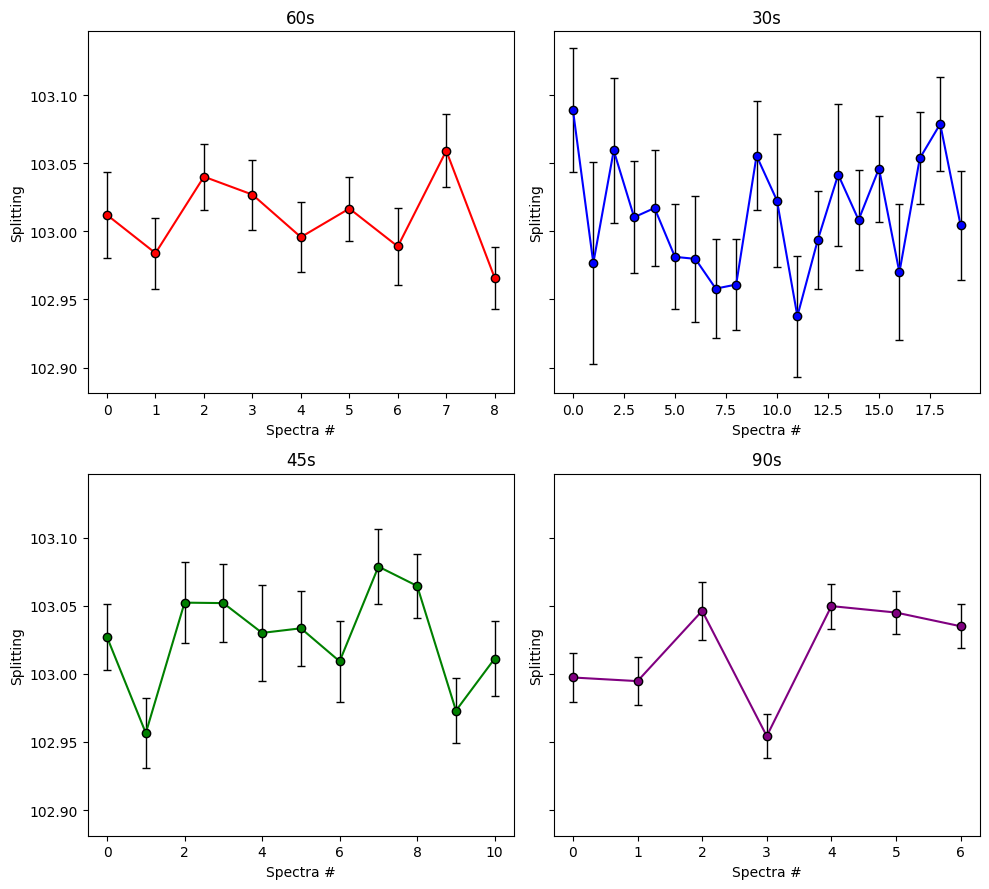

In [43]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(10, 9),sharey=True)

# Map each panel to dataset
datasets = [
    ('60s', dict_60s_all['df_Merge_1av'], 'red'),
    ('30s', dict_30s_all['df_Merge_1av'], 'blue'),
    ('45s', dict_45s_all['df_Merge_1av'], 'green'),
    ('90s', dict_90s_all['df_Merge_1av'], 'purple')
]

axes = axes.flatten()

for ax, (label, df, color) in zip(axes, datasets):
    
    x = df.index.to_numpy()
    y = df['Splitting'].to_numpy()
    yerr = df['Split_σ'].to_numpy()
    
    ax.errorbar(
        x, y,
        yerr=yerr,
        fmt='-o',
        color=color,
        mec='k',
        mfc=color,
        ecolor='k',
        elinewidth=1,
        capsize=3
    )
    
    ax.set_title(label)
    ax.set_xlabel('Spectra #')
    ax.set_ylabel('Splitting')

# Optional: cleaner layout
plt.tight_layout()

plt.show()

In [26]:
dict_30s_all['df_Merge_1av']

,filename,Splitting,Split_σ,Diad1_Combofit_Cent,Diad1_cent_err,Diad1_Combofit_Height,Diad1_Voigt_Cent,Diad1_Voigt_Area,Diad1_Voigt_Sigma,Diad1_Residual,...,Diad1_Asym50,Diad1_Asym70,Diad1_Yuan2017_sym_factor,Diad1_Remigi2021_BSF,Diad2_Asym50,Diad2_Asym70,Diad2_Yuan2017_sym_factor,Diad2_Remigi2021_BSF,Diad1_PDF_Model,Diad2_PDF_Model
0,1,103.089216,0.045597,1286.155588,0.035905,49.650629,1286.155588,58.816450,0.556432,2.646400,...,1.008696,1.038991,0.009677,0.022414,1.331950,1.402640,0.238037,0.007873,PseudoVoigtModel,PseudoVoigtModel
1,1,102.976757,0.074164,1286.243280,0.068814,51.243550,1286.243280,60.917076,0.378399,2.174919,...,1.135458,1.233333,0.102514,0.014769,1.230769,1.261146,0.171594,0.007642,PseudoVoigtModel,PseudoVoigtModel
2,1,103.059401,0.052893,1286.190220,0.048502,50.142600,1286.190220,65.590940,0.427125,2.224080,...,1.089147,1.141618,0.076154,0.017036,1.143357,1.132231,0.128838,0.011985,PseudoVoigtModel,PseudoVoigtModel
3,1,103.010392,0.041140,1286.291223,0.038941,44.358086,1286.291223,43.153457,0.456963,2.702923,...,1.346774,1.470032,0.316926,0.020603,1.037671,1.035616,0.028580,0.007684,PseudoVoigtModel,PseudoVoigtModel
4,1,103.017151,0.042930,1286.230272,0.030435,58.619778,1286.230272,54.722067,0.432854,2.371599,...,1.151394,1.160000,0.131064,0.014768,1.308333,1.378738,0.394667,0.018044,PseudoVoigtModel,PseudoVoigtModel
5,1,102.981309,0.038494,1286.242360,0.033099,60.187003,1286.242360,53.134820,0.393581,2.496375,...,1.176724,1.228188,0.139111,0.013079,1.147482,1.132394,0.131804,0.010750,PseudoVoigtModel,PseudoVoigtModel
6,1,102.979817,0.046201,1286.285500,0.029380,60.767291,1286.285500,60.403699,0.439555,2.618616,...,1.180451,1.175439,0.158636,0.014467,1.288538,1.329154,0.178120,0.004976,PseudoVoigtModel,PseudoVoigtModel
7,1,102.957973,0.036352,1286.294691,0.030189,62.999489,1286.294691,67.908817,0.442894,2.344324,...,1.184502,1.180516,0.163429,0.014060,1.268199,1.298780,0.225882,0.010343,PseudoVoigtModel,PseudoVoigtModel
8,1,102.960969,0.033360,1286.300039,0.028166,57.359946,1286.300039,60.009742,0.472153,2.567761,...,1.288390,1.326531,0.272328,0.016463,1.254545,1.282421,0.232238,0.010924,PseudoVoigtModel,PseudoVoigtModel
9,1,103.055517,0.040027,1286.277348,0.035514,63.447631,1286.277348,52.015210,0.364097,2.562229,...,1.229075,1.305556,0.166811,0.011477,1.078689,1.078125,0.074416,0.011446,PseudoVoigtModel,PseudoVoigtModel


In [18]:
summary_df_120s

,Accumulations,Mean_Split_σ,Std_Split_σ,Mean_pk1_σ,Std_pk1_σ,Mean_pk2_σ,Std_pk2_σ,Split,Dens,Dens_err_overall,Dens_err_pks,std_from_reps_pk1,std_from_reps_pk2,std_from_reps_split,NumberRowsAveraged
0,1,0.014855,0.000406,0.012882,0.000622,0.007376,0.000317,103.013408,0.014533,0.007082,0.005886,0.019716,0.009163,0.024631,5
1,2,0.011226,0.000205,0.009800,0.000359,0.005463,0.000250,103.019490,0.016239,0.005937,0.004448,0.015800,0.005802,0.020442,4
2,3,0.009547,0.000169,0.008354,0.000193,0.004616,0.000204,103.021776,0.016885,0.005454,0.003783,0.008157,0.004716,0.012866,3
3,4,0.008986,0.000036,0.007981,0.000004,0.004130,0.000069,103.014881,0.016279,0.005303,0.003561,0.001910,0.002767,0.004677,2
4,5,0.008243,0.000000,0.007273,0.000000,0.003879,0.000000,103.010695,0.014624,0.005115,0.003266,0.000000,0.000000,0.000000,1


In [4]:
## Lets look at how errors are behaving

In [14]:
summary_df_120s

,Accumulations,Mean_Split_σ,Std_Split_σ,Mean_pk1_σ,Std_pk1_σ,Mean_pk2_σ,Std_pk2_σ,Split,Dens,Dens_err_overall,Dens_err_pks,std_from_reps_pk1,std_from_reps_pk2,std_from_reps_split,NumberSpectra
0,1,0.014855,0.000406,0.012882,0.000622,0.007376,0.000317,103.013408,0.014533,0.007082,0.005886,0.019716,0.009163,0.024631,5
1,2,0.011226,0.000205,0.009800,0.000359,0.005463,0.000250,103.019490,0.016239,0.005937,0.004448,0.015800,0.005802,0.020442,4
2,3,0.009547,0.000169,0.008354,0.000193,0.004616,0.000204,103.021776,0.016885,0.005454,0.003783,0.008157,0.004716,0.012866,3
3,4,0.008986,0.000036,0.007981,0.000004,0.004130,0.000069,103.014881,0.016279,0.005303,0.003561,0.001910,0.002767,0.004677,2
4,5,0.008243,0.000000,0.007273,0.000000,0.003879,0.000000,103.010695,0.014624,0.005115,0.003266,0.000000,0.000000,0.000000,1


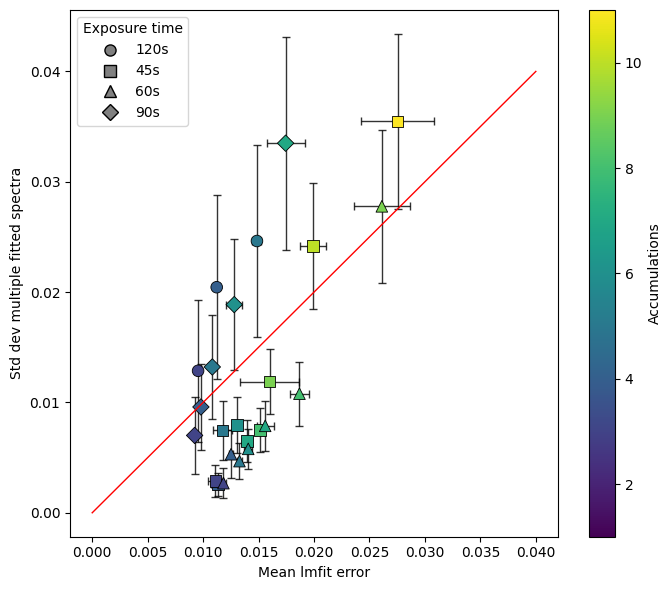

<Figure size 640x480 with 0 Axes>

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# -----------------------------
# Marker for each exposure time
# -----------------------------
marker_dict = {
    '120s': 'o',
    '45s': 's',
    '60s': '^',
    '90s': 'D'
}

# -----------------------------
# Combine all NumberSpectra values
# so colors are normalized globally
# -----------------------------
all_nspec = np.concatenate([
    summary_df_120s['Accumulations'].to_numpy(),
    summary_df_45s['Accumulations'].to_numpy(),
    summary_df_60s['Accumulations'].to_numpy(),
    summary_df_90s['Accumulations'].to_numpy()
])

norm = plt.Normalize(all_nspec.min(), all_nspec.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(7, 6))

# -----------------------------
# Helper to plot one dataframe
# x = Mean_Split_σ
# xerr = Std_Split_σ
# y = std_from_reps_split
# yerr = uncertainty on the std
#      = s / sqrt(2*(N-1))
# where N = NumberSpectra
# -----------------------------
def plot_df_with_errors(df, time_label):
    df = df[df['NumberRowsAveraged'] > 2]
    marker = marker_dict[time_label]

    x = df['Mean_Split_σ'].to_numpy()
    xerr = df['Std_Split_σ'].to_numpy()

    y = df['std_from_reps_split'].to_numpy()
    N = df['NumberRowsAveraged'].to_numpy()

    # Avoid divide-by-zero for N <= 1
    yerr = np.full_like(y, np.nan, dtype=float)
    valid = N > 1
    yerr[valid] = y[valid] / np.sqrt(2 * (N[valid] - 1))

    # Plot error bars first
    for i in range(len(df)):
        ax.errorbar(
            x[i], y[i],
            xerr=xerr[i],
            yerr=yerr[i],
            fmt='none',
            ecolor='k',
            elinewidth=1,
            capsize=3,
            alpha=0.8,
            zorder=1
        )

    # Plot points colored by NumberSpectra
    sc = ax.scatter(
        x, y,
        c=N,
        cmap=cmap,
        norm=norm,
        marker=marker,
        s=70,
        edgecolors='k',
        linewidths=0.6,
        zorder=2
    )
    return sc

# -----------------------------
# Plot all datasets
# -----------------------------
sc = plot_df_with_errors(summary_df_120s, '120s')
plot_df_with_errors(summary_df_45s, '45s')
plot_df_with_errors(summary_df_60s, '60s')
plot_df_with_errors(summary_df_90s, '90s')

# -----------------------------
# 1:1 line
# -----------------------------
ax.plot([0, 0.04], [0, 0.04], '-r', lw=1)

# -----------------------------
# Labels
# -----------------------------
ax.set_xlabel('Mean lmfit error')
ax.set_ylabel('Std dev multiple fitted spectra')

# -----------------------------
# Colorbar for NumberSpectra
# -----------------------------
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Accumulations')

# -----------------------------
# Custom legend for marker shapes
# -----------------------------
legend_elements = [
    Line2D([0], [0], marker=marker_dict['120s'], color='w', label='120s',
           markerfacecolor='gray', markeredgecolor='k', markersize=8),
    Line2D([0], [0], marker=marker_dict['45s'], color='w', label='45s',
           markerfacecolor='gray', markeredgecolor='k', markersize=8),
    Line2D([0], [0], marker=marker_dict['60s'], color='w', label='60s',
           markerfacecolor='gray', markeredgecolor='k', markersize=8),
    Line2D([0], [0], marker=marker_dict['90s'], color='w', label='90s',
           markerfacecolor='gray', markeredgecolor='k', markersize=8),
]

ax.legend(handles=legend_elements, title='Exposure time')

plt.tight_layout()
plt.show()
plt.savefig('ErrorAveragingUluMI1.png', dpi=200)

## Lets make a pretty plot to show the difference

In [5]:
import os
spectra_path=os.getcwd()
files_30=pf.get_data(path=spectra_path,
                       filename='2 30s_20x_still_12mW.txt', filetype='headless_txt')
files_120=pf.get_data(path=spectra_path,
                       filename='4 120s_5x_still_12mW.txt', filetype='headless_txt')




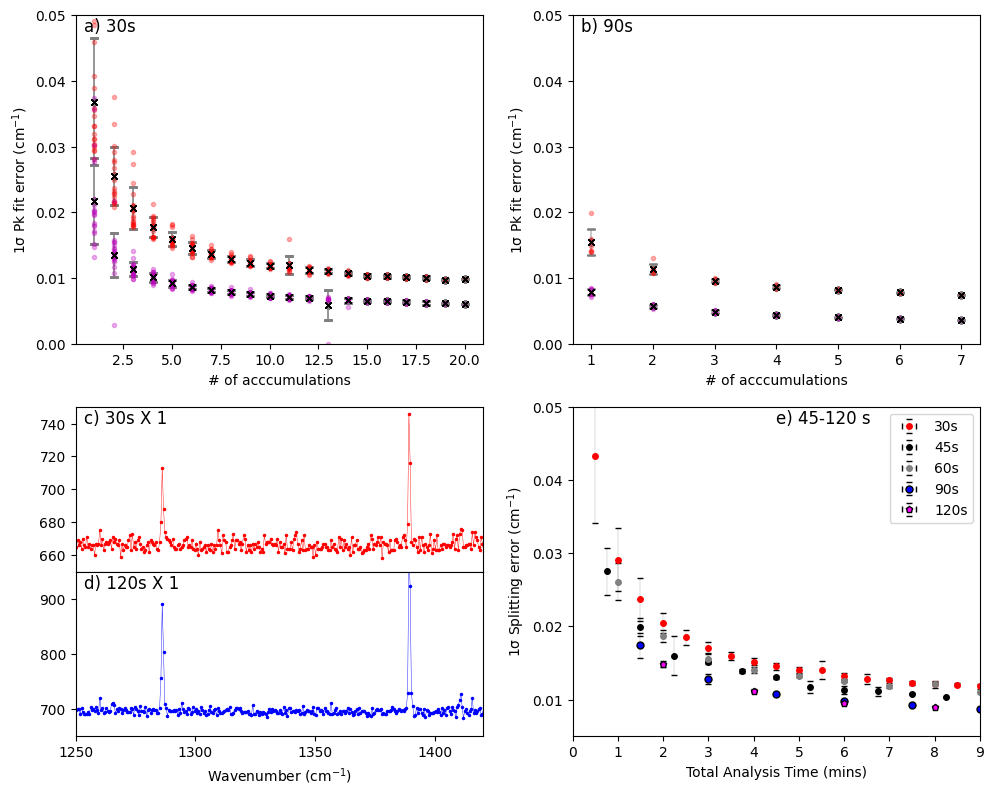

In [11]:
#fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,8))
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 2)

# Create subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
# Create a new grid for the third position
inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1, 0], hspace=0)
ax3a = fig.add_subplot(inner_grid[0])
ax3b = fig.add_subplot(inner_grid[1])
ax4 = fig.add_subplot(gs[1, 1])

# Loop over different dictionaries
df_dict=dict_30s_all

# This is the average of all the accumulations
ax1.annotate("a) 30s", xy=(0.02, 0.95), xycoords="axes fraction", fontsize=12)
summary_df=summary_df_30s

for i in range(len(summary_df)):
    
    
  

    # ax1.errorbar(summary_df['Accumulations'], summary_df['Mean_Split_σ'], xerr=0, yerr=0*summary_df['Std_Split_σ'],
    #          fmt='p', ecolor='k', elinewidth=0.1, mfc='white', ms=5, mec='k', capsize=2)
    ax1.errorbar(summary_df['Accumulations'], summary_df['Mean_pk1_σ'], xerr=0, yerr=summary_df['Std_pk1_σ'],
             fmt='x', ecolor='grey', elinewidth=0.1, mfc='red', ms=4, mec='k', capsize=3)
    ax1.errorbar(summary_df['Accumulations'], summary_df['Mean_pk2_σ'], xerr=0, yerr=summary_df['Std_pk2_σ'],
             fmt='x', ecolor='grey', elinewidth=0.1, mfc='magenta', ms=4, mec='k', capsize=3)
    
df_dict=dict_30s_all
for key, df in df_dict.items():
    parts = key.split('av')[0].split('_')
    # Extract the number, which should be the last part
    number = int(parts[-1])
    

    #ax1.plot(number+0*df['Split_σ'], df['Split_σ'], '.k', alpha=0.3)
    ax1.plot(number+0*df['Diad1_cent_err'], df['Diad1_cent_err'], '.r', alpha=0.3)
    ax1.plot(number+0*df['Diad2_cent_err'], df['Diad2_cent_err'], '.m', alpha=0.3)


#This plots the individual accumulations
    


ax2.annotate("b) 90s", xy=(0.02, 0.95), xycoords="axes fraction", fontsize=12)
summary_df=summary_df_90s

for i in range(len(summary_df)):
    
   
  

    # ax2.errorbar(summary_df['Accumulations'], summary_df['Mean_Split_σ'], xerr=0, yerr=0*summary_df['Std_Split_σ'],
    #          fmt='p', ecolor='k', elinewidth=0.1, mfc='white', ms=5, mec='k', capsize=2)
    ax2.errorbar(summary_df['Accumulations'], summary_df['Mean_pk1_σ'], xerr=0, yerr=summary_df['Std_pk1_σ'],
             fmt='x', ecolor='grey', elinewidth=0.1, mfc='red', ms=4, mec='k', capsize=3)
    ax2.errorbar(summary_df['Accumulations'], summary_df['Mean_pk2_σ'], xerr=0, yerr=summary_df['Std_pk2_σ'],
             fmt='x', ecolor='grey', elinewidth=0.1, mfc='magenta', ms=4, mec='k', capsize=3)
    
df_dict=dict_90s_all
for key, df in df_dict.items():
    parts = key.split('av')[0].split('_')
    # Extract the number, which should be the last part
    number = int(parts[-1])
    

    #ax2.plot(number+0*df['Split_σ'], df['Split_σ'], '.k', alpha=0.3)
    ax2.plot(number+0*df['Diad1_cent_err'], df['Diad1_cent_err'], '.r', alpha=0.3)
    ax2.plot(number+0*df['Diad2_cent_err'], df['Diad2_cent_err'], '.m', alpha=0.3)

ax1.set_ylabel('1σ Pk fit error (cm$^{-1})$')
ax2.set_ylabel('1σ Pk fit error (cm$^{-1})$')
#ax2.set_ylabel('1σ Splitting (cm$^{-1})$')

#This plots the individual accumulations
import os
spectra_path=os.getcwd()

            

ms=3
ax3a.annotate("c) 30s X 1", xy=(0.02, 0.9), xycoords="axes fraction", fontsize=12)
ax3b.annotate("d) 120s X 1", xy=(0.02, 0.9), xycoords="axes fraction", fontsize=12)
for i in range(1, 2):
    l=i*1000
    
    ax3a.plot(files_30[:, 0], files_30[:, i+1], '.-r', lw=0.3, ms=ms)
    ax3b.plot(files_120[:, 0], files_120[:, i+1], '.-b', lw=0.3, ms=ms)

    # Averages
    j=0
    n=6
    y_mean_45 = np.mean(files_30[:, j+1:j+n+1], axis=1)
    y_mean_120 = np.mean(files_120[:, j+1:j+n+1], axis=1)




# Now lets plot the error on splitting for all of them

# ax4.plot((1/60)*summary_df_120s['Accumulations']*120, summary_df_120s['Mean_Split_σ'], 'pk', mfc='white', label='120s')
# ax4.plot((1/60)*summary_df_90s['Accumulations']*90, summary_df_90s['Mean_Split_σ'], 'o', mfc='blue', label='90s')
# ax4.plot((1/60)*summary_df_60s['Accumulations']*60, summary_df_60s['Mean_Split_σ'], '.', color='grey', label='60s')
# ax4.plot((1/60)*summary_df_45s['Accumulations']*45, summary_df_45s['Mean_Split_σ'], 'dk', mfc='red', label='45s')

# 
caps=2








ax4.errorbar((1/60)*summary_df_30s['Accumulations']*30, summary_df_30s['Mean_Split_σ'], xerr=0, yerr=summary_df_30s['Std_Split_σ'],
             fmt='o', ecolor='k', elinewidth=0.1, mfc='r', ms=5, lw=2, mec='None', capsize=caps, label='30s')

ax4.errorbar((1/60)*summary_df_45s['Accumulations']*45, summary_df_45s['Mean_Split_σ'], xerr=0, yerr=summary_df_45s['Std_Split_σ'],
             fmt='o', ecolor='k', elinewidth=0.1, mfc='k', ms=5, lw=2, mec='None', capsize=caps, label='45s')

ax4.errorbar((1/60)*summary_df_60s['Accumulations']*60, summary_df_60s['Mean_Split_σ'], xerr=0, yerr=summary_df_60s['Std_Split_σ'],
             fmt='o', ecolor='k', elinewidth=0.1, mfc='grey', ms=5, mec='None', capsize=caps, label='60s')

ax4.errorbar((1/60)*summary_df_90s['Accumulations']*90, summary_df_90s['Mean_Split_σ'], xerr=0, yerr=summary_df_90s['Std_Split_σ'],
             fmt='o', ecolor='k', elinewidth=0.1, mfc='blue', ms=5, mec='k', capsize=caps, label='90s')

ax4.errorbar((1/60)*summary_df_120s['Accumulations']*120, summary_df_120s['Mean_Split_σ'], xerr=0, yerr=summary_df_120s['Std_Split_σ'],
             fmt='p', ecolor='k', elinewidth=0.1, mfc='magenta', ms=5, mec='k', capsize=caps, label='120s')


ax4.annotate("e) 45-120 s", xy=(0.5, 0.95), xycoords="axes fraction", fontsize=12)
ax4.legend()


ax3a.set_xticks([])
ax3b.set_xticks([1250, 1300, 1350, 1400])
ax3b.set_xlabel('Wavenumber (cm$^{-1}$)')
ax1.set_xlabel('# of acccumulations')
ax2.set_xlabel('# of acccumulations')
ax4.set_ylabel('1σ Splitting error (cm$^{-1})$')
ax4.set_xlabel('Total Analysis Time (mins)')
ax4.set_xlim([0, 9])
fig.tight_layout()
ax4.set_ylim([0.005, 0.05])

#test=np.column_stack((files[:, 0], files[:, 1]))
ax3a.set_ylim([650, 750])
ax3b.set_ylim([650, 950])
ax3a.set_xlim([1250, 1420])
ax3b.set_xlim([1250, 1420])
## Now lets plot averages
ax1.set_ylim([0, 0.05])
ax2.set_ylim([0, 0.05])


fig.savefig('MaunaUluBub1_errors_python.png', dpi=200)

In [ ]:
summary_df_200s

In [ ]:
# Lets plot it for each peak individually
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.plot((1/60)*summary_df_120s['Accumulations']*120, summary_df_120s['Mean_pk1_σ'], '.r', label='120s')
ax1.plot((1/60)*summary_df_90s['Accumulations']*90, summary_df_90s['Mean_pk1_σ'], '.b', label='90s')
ax1.plot((1/60)*summary_df_60s['Accumulations']*60, summary_df_60s['Mean_pk1_σ'], '.c', label='60s')
ax1.plot((1/60)*summary_df_45s['Accumulations']*45, summary_df_45s['Mean_pk1_σ'], '.g', label='45s')

ax2.plot((1/60)*summary_df_120s['Accumulations']*120, summary_df_120s['Mean_pk2_σ'], '.r', label='120s')
ax2.plot((1/60)*summary_df_90s['Accumulations']*90, summary_df_90s['Mean_pk2_σ'], '.b', label='90s')
ax2.plot((1/60)*summary_df_60s['Accumulations']*60, summary_df_60s['Mean_pk2_σ'], '.c', label='60s')
ax2.plot((1/60)*summary_df_45s['Accumulations']*45, summary_df_45s['Mean_pk2_σ'], '.g', label='45s')

In [ ]:

Pf120 = np.poly1d(np.polyfit(summary_df_120s['Accumulations'], summary_df_120s['Mean_Split_σ'],
                          5))
Px = np.linspace(1, 9, 101)
Py120 = Pf120(Px)
#plt.plot(Px, Py120, '-r')

# Pf90= np.poly1d(np.polyfit(summary_df_90s['Accumulations'], summary_df_90s['Mean_Split_σ'],
#                           3))
# Px90 = np.linspace(1, 6, 101)
# Py90 = Pf90(Px)
# plt.plot(Px, Py120, '-r')
# plt.plot(Px90, Py90, '-b')
plt.plot(summary_df_120s['Accumulations'], summary_df_120s['Mean_Split_σ'], '.r', label='120s')
plt.plot(summary_df_90s['Accumulations'], summary_df_90s['Mean_Split_σ'], '.b', label='90s')
plt.plot(summary_df_60s['Accumulations'], summary_df_60s['Mean_Split_σ'], '.c', label='60s')
plt.plot(summary_df_45s['Accumulations'], summary_df_45s['Mean_Split_σ'], '.g', label='45s')
plt.legend()
plt.ylabel('Sigma')
plt.xlabel('Number acquisitions')

In [ ]:
summary_df_120s

In [ ]:

Pf120 = np.poly1d(np.polyfit(summary_df_120s['Accumulations'], summary_df_120s['Mean_Split_σ'],
                          5))
Px = np.linspace(1, 9, 101)
Py120 = Pf120(Px)
#plt.plot(Px, Py120, '-r')

# Pf90= np.poly1d(np.polyfit(summary_df_90s['Accumulations'], summary_df_90s['Mean_Split_σ'],
#                           3))
# Px90 = np.linspace(1, 6, 101)
# Py90 = Pf90(Px)
# plt.plot(Px, Py120, '-r')
# plt.plot(Px90, Py90, '-b')
plt.plot((1/60)*summary_df_120s['Accumulations']*120, summary_df_120s['Mean_Split_σ'], '.r', label='120s')
plt.plot((1/60)*summary_df_90s['Accumulations']*90, summary_df_90s['Mean_Split_σ'], '.b', label='90s')
plt.plot((1/60)*summary_df_60s['Accumulations']*60, summary_df_60s['Mean_Split_σ'], '.c', label='60s')
plt.plot((1/60)*summary_df_45s['Accumulations']*45, summary_df_45s['Mean_Split_σ'], '.g', label='45s')
plt.legend()
plt.ylabel('Sigma (cm-1)')
plt.xlabel('Time (mins)')
plt.plot([(45*3)/60, (45*3)/60], [0.008, 0.022], '-r')
plt.plot([3*(45*3)/60, 3*(45*3)/60], [0.008, 0.022], '-r')

In [ ]:
summary_df_120s

In [ ]:



Pf120 = np.poly1d(np.polyfit(summary_df_120s['Accumulations'], summary_df_120s['Mean_Split_σ'],
                          5))
Px = np.linspace(1, 9, 101)
Py120 = Pf120(Px)
#plt.plot(Px, Py120, '-r')

# Pf90= np.poly1d(np.polyfit(summary_df_90s['Accumulations'], summary_df_90s['Mean_Split_σ'],
#                           3))
# Px90 = np.linspace(1, 6, 101)
# Py90 = Pf90(Px)
# plt.plot(Px, Py120, '-r')
# plt.plot(Px90, Py90, '-b')
plt.plot((1/60)*summary_df_120s['Accumulations']*120, summary_df_120s['Dens'], '.r', label='120s')
plt.plot((1/60)*summary_df_90s['Accumulations']*90, summary_df_90s['Dens'], '.b', label='90s')
plt.plot((1/60)*summary_df_60s['Accumulations']*60, summary_df_60s['Dens'], '.c', label='60s')
plt.plot((1/60)*summary_df_45s['Accumulations']*45, summary_df_45s['Dens'], '.g', label='45s')
plt.legend()
plt.ylabel('Density')
plt.xlabel('Total ACq Time (mins)')
plt.ticklabel_format(useOffset=False)
# plt.plot([(45*3)/60, (45*3)/60], [0.008, 0.022], '-r')
# plt.plot([3*(45*3)/60, 3*(45*3)/60], [0.008, 0.022], '-r')

In [ ]:

Pf120 = np.poly1d(np.polyfit(summary_df_120s['Accumulations'], summary_df_120s['Mean_Split_σ'],
                          5))
Px = np.linspace(1, 9, 101)
Py120 = Pf120(Px)
#plt.plot(Px, Py120, '-r')

# Pf90= np.poly1d(np.polyfit(summary_df_90s['Accumulations'], summary_df_90s['Mean_Split_σ'],
#                           3))
# Px90 = np.linspace(1, 6, 101)
# Py90 = Pf90(Px)
# plt.plot(Px, Py120, '-r')
# plt.plot(Px90, Py90, '-b')
plt.plot((1/60)*summary_df_120s['Accumulations']*120, summary_df_120s['Split'], '.r', label='120s')
plt.plot((1/60)*summary_df_90s['Accumulations']*90, summary_df_90s['Split'], '.b', label='90s')
plt.plot((1/60)*summary_df_60s['Accumulations']*60, summary_df_60s['Split'], '.c', label='60s')
plt.plot((1/60)*summary_df_45s['Accumulations']*45, summary_df_45s['Split'], '.g', label='45s')
plt.legend()
plt.ylabel('split')
plt.xlabel('Time (mins)')
plt.ticklabel_format(useOffset=False)
# plt.plot([(45*3)/60, (45*3)/60], [0.008, 0.022], '-r')
# plt.plot([3*(45*3)/60, 3*(45*3)/60], [0.008, 0.022], '-r')

In [ ]:

Pf120 = np.poly1d(np.polyfit(summary_df_120s['Accumulations'], summary_df_120s['Mean_Split_σ'],
                          5))
Px = np.linspace(1, 9, 101)
Py120 = Pf120(Px)
#plt.plot(Px, Py120, '-r')

# Pf90= np.poly1d(np.polyfit(summary_df_90s['Accumulations'], summary_df_90s['Mean_Split_σ'],
#                           3))
# Px90 = np.linspace(1, 6, 101)
# Py90 = Pf90(Px)
# plt.plot(Px, Py120, '-r')
# plt.plot(Px90, Py90, '-b')
plt.plot((1/60)*summary_df_120s['Accumulations']*120, summary_df_120s['Mean_Split_σ'], '.r', label='120s')
plt.plot((1/60)*summary_df_90s['Accumulations']*90, summary_df_90s['Mean_Split_σ'], '.b', label='90s')
plt.plot((1/60)*summary_df_60s['Accumulations']*60, summary_df_60s['Mean_Split_σ'], '.c', label='60s')
plt.plot((1/60)*summary_df_45s['Accumulations']*45, summary_df_45s['Mean_Split_σ'], '.g', label='45s')
plt.legend()
plt.ylabel('Sigma')
plt.xlabel('Time (mins)')
plt.plot([(45*3)/60, (45*3)/60], [0.008, 0.022], '-r')
plt.plot([3*(45*3)/60, 3*(45*3)/60], [0.008, 0.022], '-r')

In [ ]:
summary_df_120s

In [ ]:
df_dict=dict_120s_all
summary_df=summary_df_120s
for key, df in df_dict.items():
    parts = key.split('av')[0].split('_')
    # Extract the number, which should be the last part
    number = int(parts[-1])
    print(number)

    #plt.plot(number+0*df['Split_σ'], df['Split_σ'], 'xk', alpha=0.3)
for i in range(len(summary_df)):
    
    plt.errorbar(summary_df['Accumulations'], summary_df['Mean_Split_σ'], xerr=0, yerr=summary_df['Std_Split_σ'],
             fmt='o', ecolor='k', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3)
    plt.xlabel('Number averaged')
    plt.xlabel('N averaged')


df_dict=dict_90s_all
summary_df=summary_df_90s
for key, df in df_dict.items():
    parts = key.split('av')[0].split('_')
    # Extract the number, which should be the last part
    number = int(parts[-1])
    print(number)

    #plt.plot(number+0*df['Split_σ'], df['Split_σ'], 'xk', alpha=0.3)
for i in range(len(summary_df)):
    
    plt.errorbar(summary_df['Accumulations'], summary_df['Mean_Split_σ'], xerr=0, yerr=summary_df['Std_Split_σ'],
             fmt='o', ecolor='r', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3)
    plt.xlabel('Number averaged')
    plt.xlabel('N averaged')   